<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex06_mlp%2Ccnn_%EA%B0%9C%EA%B3%A0%EC%96%91%EC%9D%B4_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ex06_mlp,cnn_개고양이_이진분류.ipynb

In [ ]:
# 런타임 > 런타임 유형변경 > gpu t4
# 드라이브 연동
# 경로 이동
%cd '/content/drive/MyDrive/딥러닝'

/content/drive/MyDrive/딥러닝


## 목표
- mlp, cnn 모델을 활용하여 이미지 분류 실습을 진행해보자
- 이진 분류 성능을 비교해보자
- 성능을 높이기 위한 노력을 진행해보자
  - 이미지 증식
  - 전이학습

In [ ]:
# npz 데이터 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FileNotFoundError: [Errno 2] No such file or directory: './data/np_cats_and_dogs.npz'

In [ ]:
# keys : 딕셔너리 개념으로 데이터에 접근해야하는구나!
data['X_train'].shape
data['X_test'].shape

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# 크기 확인
print('훈련셋:', X_train.shape, y_train.shape)
print('테스트셋:', X_test.shape, y_test.shape)

# 0: cats, 1: dogs

훈련셋: (2000, 224, 224, 3) (2000,)
테스트셋: (1000, 224, 224, 3) (1000,)


### mip 모델 생성
- mlp 기반 모델 생성
- 모델 학습/평가 방법 설정
- 모델 학습 및 시각화
- 모델 평가 및 예측

In [45]:
# 환경 셋팅

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
n_features_arr = X_train[0].shape

In [ ]:
# 모델 설계 ~
# 뼈대 구축
mlp_model = Sequential()
# 입력층
# 3차원 -> 1차원: mlp는 1차원 데이터만 받아들인다!
mlp_model.add(Flatten(input_shape=(224,224,3)))
# 224 * 224 * 3 => 특성의 개수


# 중간층
mlp_model.add(Dense(256, activation='relu'))
mlp_model.add(Dense(128, activation='relu'))
mlp_model.add(Dense(64, activation='relu'))

# 이진 분류 출력층
# 0.1
# 1, sigmoid
mlp_model.add(Dense(1, activation='sigmoid'))

# 모델 요약
mlp_model.summary()

# 컴파일
mlp_model.compile(loss= 'binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

# 조기학습 중단
# 교차검증 정확도를 기준으로 5번 정도 갱신이 되지 않으면, 더이상 좋은 학습은 어렵다고 판단하여 학습 중단
f_ea = EarlyStopping(monitor='val_accuracy',
                     patience=5,
                     verbose=1)

# 학습
mlp_his = mlp_model.fit(X_train, y_train,
                        epochs=50,
                        batch_size=64,
                        validation_split=0.3,
                        callbacks=[f_ea],
                        verbose=1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │    38,535,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,576,641 (147.16 MB)

 Trainable params: 38,576,641 (147.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.5252 - loss: 3493.1523 - val_accuracy: 0.0000e+00 - val_loss: 6242.7017
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6655 - loss: 2077.1233 - val_accuracy: 0.0000e+00 - val_loss: 3294.8689
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6500 - loss: 464.7561 - val_accuracy: 0.5950 - val_loss: 146.7408
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6264 - loss: 681.9296 - val_accuracy: 0.0000e+00 - val_loss: 2539.8142
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6265 - loss: 788.4284 - val_accuracy: 0.2117 - val_loss: 508.2316
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7074 - loss: 148.4509 - val_accuracy: 0.0000e+00 - val_loss: 5146.4595
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6208 - loss: 806.0195 - val_accuracy: 0.0000e+00 - val_loss: 2394.9412
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - ac

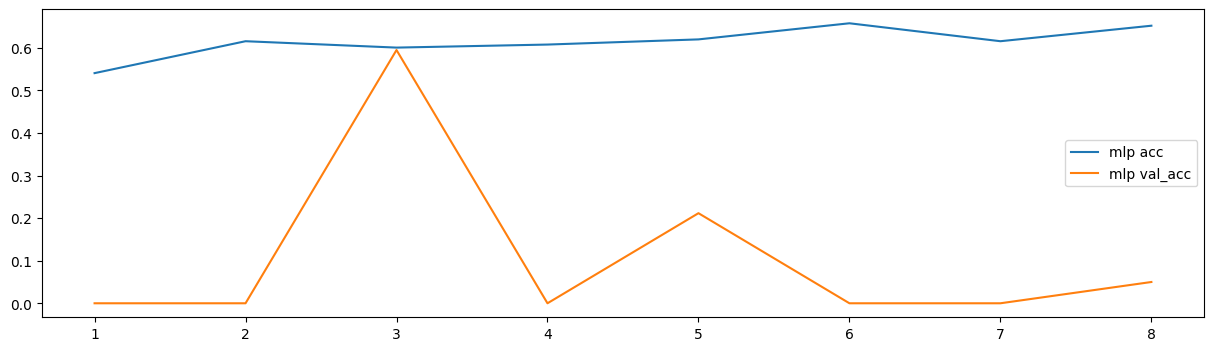

In [ ]:
# mlp 시각화
plt.figure(figsize=(15,4))
# acc, val_acc
# x 축 범위- epochs 횟수만큼
x_range = range(1, len(mlp_his.history['accuracy'])+1)
plt.plot(x_range, mlp_his.history['accuracy'], label='mlp acc')
plt.plot(x_range, mlp_his.history['val_accuracy'], label='mlp val_acc')
plt.legend()
plt.show()

In [ ]:
# 데이터의 복잡도는 높은 편
# 상대적으로 모델은 단순한 편
# 이미지를 위해 하기 위한 내부적인 구조가.. mlp는 약함
# 즉, mlp특성상 이미지 대한 학습 성능이 떨어짐


In [1]:
# gpu
# 드라이브 npz 연결
%cd '/content/drive/MyDrive/딥러닝'

/content/drive/MyDrive/딥러닝


### CNN 모델 생성
- 1. 모델 설계
    - 뼈대 구축
    - 특성추출부(합성골, Convolutional,
    pooling)
    - 분류부(전결합층, 완전연결층,mlp(이진분류))
- 2. 모델 컴파일
- 3. 학습 및 시각화
    - mlp모델 보다는 좋은걸까?
- 4. 모델 예측 및 평가


In [4]:
# data 변수에 npz 파일 불러와서 담기
import numpy as np
import matplotlib.pyplot as plt

data = np.load('/content/drive/MyDrive/딥러닝/data/cats_and_dogs_npz.npz')
data

X_train = data['X_train']
y_train = data['y_train']
X_test = data['X_test']
y_test = data['y_test']

print('훈련셋:', X_train.shape, y_train.shape)
print('테스트셋:', X_test.shape, y_test.shape)

훈련셋: (2000, 224, 224, 3) (2000,)
테스트셋: (1000, 224, 224, 3) (1000,)


In [59]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [8]:
X_train[0].shape

(224, 224, 3)

In [53]:
# 1. 모델 생성 (cnn_model2)
cnn_model2 = Sequential()

# ----- 특성 추출부 -----
cnn_model2.add(Conv2D(filters=32, kernel_size=(5,5),
                      input_shape=X_train[0].shape,
                      padding='same', strides=(1,1), activation='relu'))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model2.add(Conv2D(filters=64, kernel_size=(3,3),
                      padding='same', strides=(1,1), activation='relu'))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

cnn_model2.add(Conv2D(filters=128, kernel_size=(3,3),
                      padding='same', strides=(1,1), activation='relu'))
cnn_model2.add(MaxPooling2D(pool_size=(2,2)))

# ---- 분류부 ----
cnn_model2.add(Flatten())
cnn_model2.add(Dense(512, activation='relu'))
cnn_model2.add(Dropout(0.2))  # 20% 뉴런 비활성화
cnn_model2.add(Dense(1, activation='sigmoid'))  # 이진 분류

# 모델 요약
cnn_model2.summary()

# 2. 컴파일
cnn_model2.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

# 3. 조기학습 중단 콜백
f_ea = EarlyStopping(monitor='val_accuracy',
                     patience=5,
                     verbose=1)

# 4. 학습 (결과는 cnn_his2에 저장!)
cnn_his2 = cnn_model2.fit(X_train, y_train,
                          validation_split=0.3,
                          epochs=50,
                          batch_size=64,
                          callbacks=[f_ea],
                          verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 224, 224, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │    51,380,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,476,033 (196.37 MB)

 Trainable params: 51,476,033 (196.37 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step - accuracy: 0.5595 - loss: 1126.8005 - val_accuracy: 0.0233 - val_loss: 0.8762
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.7304 - loss: 0.5940 - val_accuracy: 0.0133 - val_loss: 1.0379
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.7543 - loss: 0.5277 - val_accuracy: 0.0750 - val_loss: 1.3587
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - accuracy: 0.7972 - loss: 0.4292 - val_accuracy: 0.1267 - val_loss: 1.9172
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 154ms/step - accuracy: 0.8794 - loss: 0.2925 - val_accuracy: 0.2633 - val_loss: 2.1541
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - accuracy: 0.9151 - loss: 0.2082 - val_accuracy: 0.3100 - val_loss: 2.6755
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.9286 - loss: 0.2084 - val_accuracy: 0.1683 - val_loss: 3.6884
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - accuracy: 0.9681 - loss: 0.1061 - val_accuracy

In [63]:
cnn_model2.compile(loss='binary_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

f_ea = EarlyStopping(monitor='val_accuracy', patience=5, verbose=1)

cnn_his2 = cnn_model2.fit(train_generator,
                          validation_data=test_generator,
                          epochs=20)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 33s 875ms/step - accuracy: 0.5980 - loss: 0.6586 - val_accuracy: 0.6410 - val_loss: 0.6330
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 777ms/step - accuracy: 0.6443 - loss: 0.6370 - val_accuracy: 0.6130 - val_loss: 0.6831
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 750ms/step - accuracy: 0.6488 - loss: 0.6580 - val_accuracy: 0.6610 - val_loss: 0.6136
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 746ms/step - accuracy: 0.6497 - loss: 0.6320 - val_accuracy: 0.6810 - val_loss: 0.6056
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 780ms/step - accuracy: 0.6627 - loss: 0.6222 - val_accuracy: 0.6670 - val_loss: 0.6052
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 783ms/step - accuracy: 0.6755 - loss: 0.6039 - val_accuracy: 0.6740 - val_loss: 0.5947
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 784ms/step - accuracy: 0.6734 - loss: 0.6050 - val_accuracy: 0.7140 - val_loss: 0.5623
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 778ms/step - accuracy: 0.7040 - loss: 0.5937 - val_accu

In [61]:
# Create ImageDataGenerators for training and validation/testing

# Define data augmentation parameters for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Define data augmentation parameters for testing (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create generators from the numpy arrays
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=64,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=64,
    shuffle=False # Keep data in order for evaluation
)

print("Data generators created.")

Data generators created.


In [62]:
# Now, train the model using the generators
cnn_his2 = cnn_model2.fit(
    train_generator,
    epochs=50, # Increased epochs for better training with data augmentation
    validation_data=test_generator,
    callbacks=[f_ea],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 32s 902ms/step - accuracy: 0.5059 - loss: 0.6951 - val_accuracy: 0.5146 - val_loss: 0.6890
Epoch 2/50
 1/31 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.5156 - loss: 0.6797

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5156 - loss: 0.6797 - val_accuracy: 0.5177 - val_loss: 0.6887
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 751ms/step - accuracy: 0.5238 - loss: 0.6874 - val_accuracy: 0.6135 - val_loss: 0.6571
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.5938 - loss: 0.6476 - val_accuracy: 0.6167 - val_loss: 0.6564
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 26s 836ms/step - accuracy: 0.5902 - loss: 0.6749 - val_accuracy: 0.5198 - val_loss: 0.6886
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.5469 - loss: 0.6733 - val_accuracy: 0.5750 - val_loss: 0.6681
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 760ms/step - accuracy: 0.5750 - loss: 0.6775 - val_accuracy: 0.6292 - val_loss: 0.6593
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.6406 - loss: 0.6629 - val_accuracy: 0.6323 - val_loss: 0.6604
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 755ms/step - accuracy: 0.5982 - loss: 0.6602 - val_accuracy: 0.6083 - val_

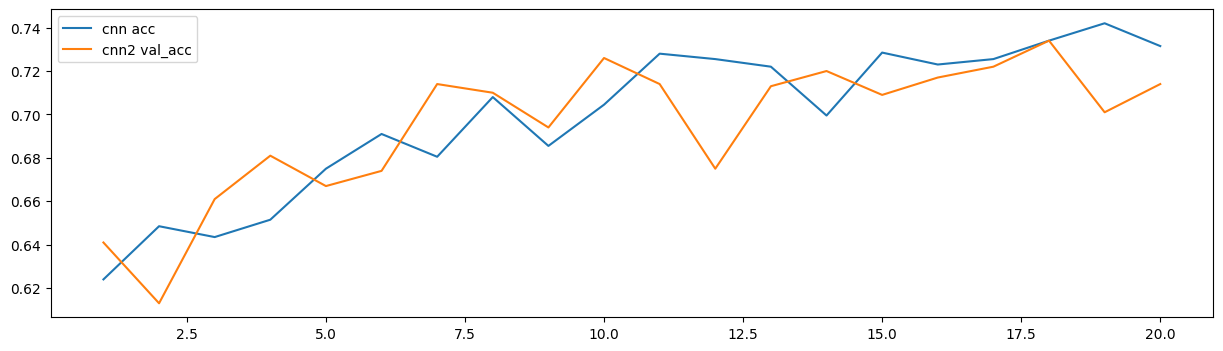

In [65]:
# 시각화
# cnn accuracy, val_accuracy 시각화
# mlp 시각화
plt.figure(figsize=(15,4))
# acc, val_acc
# x 축 범위- epochs 횟수만큼
x_range = range(1, len(cnn_his2.history['accuracy'])+1)
plt.plot(x_range, cnn_his2.history['accuracy'], label='cnn acc')
plt.plot(x_range, cnn_his2.history['val_accuracy'], label='cnn2 val_acc')
plt.legend()
plt.show()

In [ ]:
# CNN 모델 활용 학습 -> 생각보다 엄청 성능이 좋지는 않음
# 과대적합 확률이 높아보임, 과대적합으로 보여짐
# cnn 특성상 train 특성 집중도 높아짐! -> 반대로 val 집중도, acc 떨어짐
# mlp vs cnn : 과대적합일 지언정 train 에 대한 학습이 제대로된 cnn 모델이 단순 mlp 보다는 나음

# 다양한 형태의 데이터의 특성을 학습시킬 필요가 있지 않은지?
# 데이터 측면 노력 가능
# 모델 측면 노력 가능

### 데이터 증식을 통한 cnn 모델 성능 개선
- tensorflow의 ImageDataGenerator 도구를 활용해보자
- npz 말고, 실제 filtered/train, test 실제 이미지 데이터 경로를 연결

In [57]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
# 이미지 증식을 통해 과대적합 해소한 것을 확인함
# 이미지 증식 효과적
# 이미지 증식 단점으로 학습시간이 오래 걸림